In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

In [45]:
data = pd.read_excel('Concrete_Data.xls')

In [46]:
data.info()
data = data.rename(columns={'Concrete compressive strength(MPa, megapascals) ': 'strength'})

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

In [47]:
X = data.drop(columns=['strength']).values
y = data['strength'].values

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

scaler2 = StandardScaler()
X_train = scaler2.fit_transform(X_train)
X_test = scaler2.transform(X_test)

In [50]:
model = DecisionTreeRegressor(
    random_state=42,
    criterion='squared_error',
    splitter='best',
    max_depth=11,
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Среднеквадратичная ошибка (RMSE): {rmse}")
print(f"Коэффициент детерминации (R²): {r2}")
print(f"Средняя абсолютная ошибка (MAE): {mae}")

Среднеквадратичная ошибка (RMSE): 0.3953602872946987
Коэффициент детерминации (R²): 0.8308741605955754
Средняя абсолютная ошибка (MAE): 0.25883252176822685


Нейронная сеть для hour

In [51]:
data2 = pd.read_csv('hour.csv')

In [53]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [54]:
X = data2.drop(columns=['dteday', 'instant', 'cnt']).values
y = data2['cnt'].values

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

In [57]:
X_tr = torch.FloatTensor(X_train_scaled)
y_tr = torch.FloatTensor(y_train).reshape(-1, 1)
X_te = torch.FloatTensor(X_test_scaled)
y_te = torch.FloatTensor(y_test)

In [67]:
batch_size = 256
train_dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

In [68]:
class NeuralNet2(nn.Module):
    def __init__(self, input_size=14, hidden_size=56, num_classes=1):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = NeuralNet2()

num_epochs = 50
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [69]:
total_step = len(train_loader)
loss_history = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (features, labels) in enumerate(train_loader):

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, avg_loss))

model.eval()
with torch.no_grad():
    pred_scaled = model(X_te)

    pred_numpy = pred_scaled.numpy().reshape(-1, 1)
    y_te_numpy = y_te.numpy().reshape(-1, 1)

    pred_original = scaler_y.inverse_transform(pred_numpy)
    y_test_original = scaler_y.inverse_transform(y_te_numpy)

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(y_test_original, pred_original)
    mse = mean_squared_error(y_test_original, pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, pred_original)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Epoch [1/50], Loss: 0.0841
Epoch [2/50], Loss: 0.0021
Epoch [3/50], Loss: 0.0012
Epoch [4/50], Loss: 0.0008
Epoch [5/50], Loss: 0.0006
Epoch [6/50], Loss: 0.0005
Epoch [7/50], Loss: 0.0004
Epoch [8/50], Loss: 0.0003
Epoch [9/50], Loss: 0.0003
Epoch [10/50], Loss: 0.0003
Epoch [11/50], Loss: 0.0002
Epoch [12/50], Loss: 0.0002
Epoch [13/50], Loss: 0.0002
Epoch [14/50], Loss: 0.0002
Epoch [15/50], Loss: 0.0002
Epoch [16/50], Loss: 0.0001
Epoch [17/50], Loss: 0.0001
Epoch [18/50], Loss: 0.0001
Epoch [19/50], Loss: 0.0001
Epoch [20/50], Loss: 0.0001
Epoch [21/50], Loss: 0.0001
Epoch [22/50], Loss: 0.0001
Epoch [23/50], Loss: 0.0001
Epoch [24/50], Loss: 0.0001
Epoch [25/50], Loss: 0.0001
Epoch [26/50], Loss: 0.0001
Epoch [27/50], Loss: 0.0001
Epoch [28/50], Loss: 0.0001
Epoch [29/50], Loss: 0.0000
Epoch [30/50], Loss: 0.0000
Epoch [31/50], Loss: 0.0000
Epoch [32/50], Loss: 0.0000
Epoch [33/50], Loss: 0.0001
Epoch [34/50], Loss: 0.0001
Epoch [35/50], Loss: 0.0001
Epoch [36/50], Loss: 0.0000
E

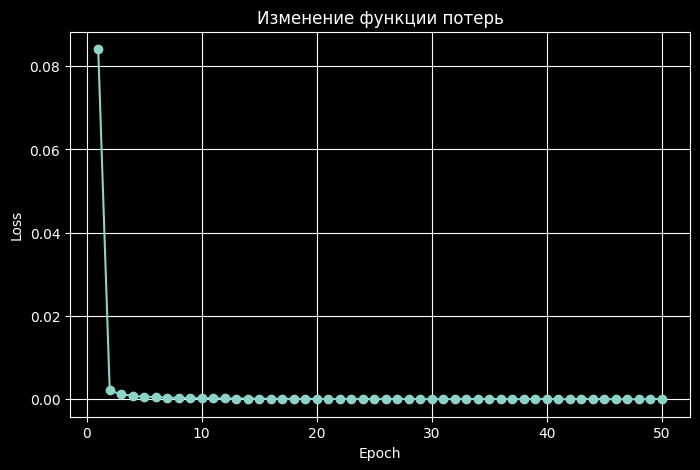

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
plt.title('Изменение функции потерь')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()